In [ ]:
import pandas as pd

df = pd.read_csv("data/data2/cohort_5_years.csv")
print(df.columns.tolist())
print(df.head())

['STRUCTURE', 'STRUCTURE_ID', 'STRUCTURE_NAME', 'ACTION', 'FREQ', 'Frequency of observation', 'TERRITORIAL_LEVEL', 'Territorial level', 'TERRITORIAL_TYPE', 'Territorial typology', 'REF_AREA', 'Reference area', 'MEASURE', 'Measure', 'AGE', 'Age', 'SEX', 'Sex', 'UNIT_MEASURE', 'Unit of measure', 'TIME_PERIOD', 'Time period', 'OBS_VALUE', 'Observation value', 'COUNTRY', 'Country', 'OBS_STATUS', 'Observation status', 'UNIT_MULT', 'Unit multiplier', 'DECIMALS', 'Decimals']
  STRUCTURE                              STRUCTURE_ID  \
0  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   
1  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   
2  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   
3  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   
4  DATAFLOW  OECD.CFE.EDS:DSD_REG_DEMO@DF_POP_5Y(1.0)   

                              STRUCTURE_NAME ACTION FREQ  \
0  Population by 5-year age groups - Regions      I    A   
1  Population by 5-year age groups - Regions      I    A   
2  P

In [10]:
print(df['TIME_PERIOD'].min(), df['TIME_PERIOD'].max())
russia_data = df[df['COUNTRY'] == 'RUS']
print(russia_data['TIME_PERIOD'].min(), russia_data['TIME_PERIOD'].max())

2018 2022
nan nan


Данные по
https://ec.europa.eu/eurostat/databrowser/view/demo_pjan/default/table?lang=en
не подходят.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from time import sleep

BASE = "https://api.census.gov/data/timeseries/idb/5year"
YEARS = [1960, 1970, 1980, 1990, 2002, 2007, 2012]

def fetch_all_countries_age_sex(year):
    params = {
        "get": "NAME,GENC,group(IDB5YEAR)",
        "time": year,
        "for": "genc standard countries and areas:*"
    }
    resp = requests.get(BASE, params=params)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    return df

nan_counts = {}
for y in YEARS:
    try:
        df = fetch_all_countries_age_sex(y)
        nan_counts[y] = df.isna().any(axis=1).sum()
        sleep(1)  # небольшая пауза между запросами
    except Exception as e:
        print(f"Error for {y}: {e}")
        nan_counts[y] = None

# Вывод числа строк с NaN
for y, n in nan_counts.items():
    print(f"{y}: {n} rows with NaN")

1960: 223 rows with NaN
1970: 217 rows with NaN
1980: 164 rows with NaN
1990: 78 rows with NaN
2002: 6 rows with NaN
2007: 4 rows with NaN
2012: 1 rows with NaN


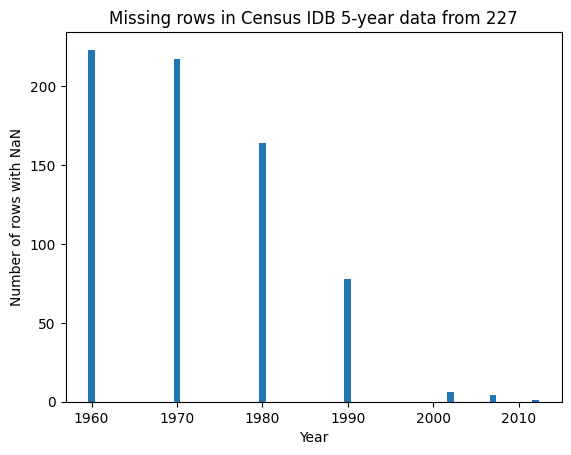

In [2]:

# Диаграмма
plt.bar(nan_counts.keys(), nan_counts.values())
plt.xlabel("Year")
plt.ylabel("Number of rows with NaN")
df_len = df.shape
plt.title(f"Missing rows in Census IDB 5-year data from {df.shape[0]}")
plt.show()


Выделим валидные для нас признаки
POP'X_Y' нужно использовать т.к. в UN данные считаются в тысячах
В UN нет NaN значений, поэтому дополним наш датасет UN.

In [3]:
print(df.columns)
print(df.head(2))

Index(['NAME', 'GENC', 'AREA_KM2', 'ASFR15_19', 'ASFR20_24', 'ASFR25_29',
       'ASFR30_34', 'ASFR35_39', 'ASFR40_44', 'ASFR45_49',
       ...
       'POP90_94', 'POP95_99', 'POP_DENS', 'RNI', 'SEXRATIO', 'SRB', 'TFR',
       'YR', 'time', 'genc standard countries and areas'],
      dtype='object', length=120)
                   NAME GENC AREA_KM2 ASFR15_19 ASFR20_24 ASFR25_29 ASFR30_34  \
0               Andorra   AD      468      12.3      41.1      73.7      89.9   
1  United Arab Emirates   AE    83600      20.1      69.6      76.0      68.5   

  ASFR35_39 ASFR40_44 ASFR45_49  ... POP90_94 POP95_99 POP_DENS    RNI  \
0      40.4      13.3       0.7  ...      417       83    182.0  0.294   
1      53.7      28.9      11.4  ...      768      189    102.9  0.920   

  SEXRATIO    SRB     TFR    YR  time genc standard countries and areas  
0    1.067  1.070  1.3572  2012  2012                                AD  
1    2.802  1.030  1.6406  2012  2012                                AE 

In [72]:
import requests
import pandas as pd
from time import sleep

BASE = "https://api.census.gov/data/timeseries/idb/5year"

def fetch_all_countries_age_sex(year):
    params = {
        "get": "NAME,GENC,AREA_KM2,POP0_4,POP5_9,POP10_14,POP15_19,POP20_24,POP25_29,"
               "POP30_34,POP35_39,POP40_44,POP45_49,POP50_54,POP55_59,POP60_64,"
               "POP65_69,POP70_74,POP75_79,POP80_84,POP85_89,POP90_94,POP95_99",
        "time": year,
        "for": "genc standard countries and areas:*"
    }
    resp = requests.get(BASE, params=params)
    resp.raise_for_status()
    data = resp.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    # Убираем лишние столбцы
    df = df.drop(columns=["genc standard countries and areas"])
    return df

all_years = []
for year in range(1970, 2023):
    try:
        df_year = fetch_all_countries_age_sex(year)
        df_year["TIME_PERIOD"] = year
        all_years.append(df_year)
        sleep(0.2)  
    except Exception as e:
        print(f"Error fetching year {year}: {e}")

df_all = pd.concat(all_years, ignore_index=True)

# Сохраняем в CSV
df_all.to_csv("data/data2/cohort_age_1970_2023.csv", index=False)
print(df_all.head())
print(f"Total rows: {len(df_all)}")


                   NAME GENC AREA_KM2 POP0_4 POP5_9 POP10_14 POP15_19  \
0               Andorra   AD      468   None   None     None     None   
1  United Arab Emirates   AE    83600   None   None     None     None   
2           Afghanistan   AF   652230   None   None     None     None   
3   Antigua and Barbuda   AG      443   None   None     None     None   
4              Anguilla   AI       91   None   None     None     None   

  POP20_24 POP25_29 POP30_34  ... POP60_64 POP65_69 POP70_74 POP75_79  \
0     None     None     None  ...     None     None     None     None   
1     None     None     None  ...     None     None     None     None   
2     None     None     None  ...     None     None     None     None   
3     None     None     None  ...     None     None     None     None   
4     None     None     None  ...     None     None     None     None   

  POP80_84 POP85_89 POP90_94 POP95_99  time TIME_PERIOD  
0     None     None     None     None  1970        1970  
1     

В США используют свой стандарт кодов стран

In [73]:
import pandas as pd

path = 'data/usa_census/GENC Standard Code Mapping Ed3.0 Update 6.xlsx'

df = pd.read_excel(path, sheet_name='GE - GENC to ISO 3166', header=None, skiprows=4)
print(df.head(6))
df = df[[1, 2]]
df.columns = ['iso3', 'genc']
print(df.head())
mapping_genc_to_iso = dict(zip(df['genc'], df['iso3']))



               0    1    2      3      4               5    6    7     8   \
0     AFGHANISTAN  AFG   AF    4.0   True     AFGHANISTAN  AFG   AF   4.0   
1        AKROTIRI  XQZ   QZ  900.0   True          <null>  NaN  NaN   NaN   
2         ALBANIA  ALB   AL    8.0   True         ALBANIA  ALB   AL   8.0   
3         ALGERIA  DZA   DZ   12.0   True         ALGERIA  DZA   DZ  12.0   
4  AMERICAN SAMOA  ASM   AS   16.0   True  AMERICAN SAMOA  ASM   AS  16.0   
5             NaN  NaN  NaN    NaN  False  American Samoa  NaN  NaN   NaN   

      9            10  
0    NaN  Correlation  
1    NaN  Correlation  
2    NaN  Correlation  
3    NaN  Correlation  
4    NaN  Correlation  
5  US-AS  Correlation  
  iso3 genc
0  AFG   AF
1  XQZ   QZ
2  ALB   AL
3  DZA   DZ
4  ASM   AS


Оставляем только нужные нам показатели в модели.

In [78]:
df_all = pd.read_csv("data/data2/cohort_age_1970_2023.csv")
if 'GENC' in df_all.columns:
    df_all['GENC'] = df_all['GENC'].map(mapping_genc_to_iso)
    df_all.rename(columns={'GENC': 'country_code'}, inplace=True)

if 'time' in df_all.columns:
    df_all.rename(columns={'time': 'year'}, inplace=True)

if 'TIME_PERIOD' in df_all.columns:
    df_all.drop(columns=['TIME_PERIOD'], inplace=True)
df_all.drop(columns=['NAME'], inplace=True)
print(df_all.columns)
print(df_all.head(2))

Index(['country_code', 'AREA_KM2', 'POP0_4', 'POP5_9', 'POP10_14', 'POP15_19',
       'POP20_24', 'POP25_29', 'POP30_34', 'POP35_39', 'POP40_44', 'POP45_49',
       'POP50_54', 'POP55_59', 'POP60_64', 'POP65_69', 'POP70_74', 'POP75_79',
       'POP80_84', 'POP85_89', 'POP90_94', 'POP95_99', 'year'],
      dtype='object')
  country_code  AREA_KM2  POP0_4  POP5_9  POP10_14  POP15_19  POP20_24  \
0          AND       468     NaN     NaN       NaN       NaN       NaN   
1          ARE     83600     NaN     NaN       NaN       NaN       NaN   

   POP25_29  POP30_34  POP35_39  ...  POP55_59  POP60_64  POP65_69  POP70_74  \
0       NaN       NaN       NaN  ...       NaN       NaN       NaN       NaN   
1       NaN       NaN       NaN  ...       NaN       NaN       NaN       NaN   

   POP75_79  POP80_84  POP85_89  POP90_94  POP95_99  year  
0       NaN       NaN       NaN       NaN       NaN  1970  
1       NaN       NaN       NaN       NaN       NaN  1970  

[2 rows x 23 columns]


In [ ]:
df_all.to_csv("data/data2/cohort_age_1970_2023.csv", index=False)

### Используем данные UN. 
Недостаток: формат Excel, данные в pop_cohort выражены в 1000

In [23]:
import pandas as pd

file_path = "data/un/population5/wpp2024_pop5yearAge.xlsx"
pop = pd.read_excel(file_path, sheet_name="Estimates")
print(pop.columns)
pop.columns = [
    "index", "variant", "region", "notes", "location_code", "iso3_code", "iso2_code", "sdmx_code",
    "type", "parent_code", "year", "Pop0_4", "Pop5_9", "Pop10_14", "Pop15_19", "Pop20_24", "Pop25_29",
    "Pop30_34", "Pop35_39", "Pop40_44", "Pop45_49", "Pop50_54", "Pop55_59", "Pop60_64", "Pop65_69",
    "Pop70_74", "Pop75_79", "Pop80_84", "Pop85_89", "Pop90_94", "Pop95_99", "Pop100plus"
]
print(pop.head(10))


Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9',
       'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13',
       'Unnamed: 14', 'Unnamed: 15', 'Unnamed: 16', 'Unnamed: 17',
       'Unnamed: 18', 'Unnamed: 19', 'Unnamed: 20', 'Unnamed: 21',
       'Unnamed: 22', 'Unnamed: 23', 'Unnamed: 24', 'Unnamed: 25',
       'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 28', 'Unnamed: 29',
       'Unnamed: 30', 'Unnamed: 31'],
      dtype='object')
  index variant region notes  \
0   NaN     NaN    NaN   NaN   
1   NaN     NaN    NaN   NaN   
2   NaN     NaN    NaN   NaN   
3   NaN     NaN    NaN   NaN   
4   NaN     NaN    NaN   NaN   
5   NaN     NaN    NaN   NaN   
6   NaN     NaN    NaN   NaN   
7   NaN     NaN    NaN   NaN   
8   NaN     NaN    NaN   NaN   
9   NaN     NaN    NaN   NaN   

                                       location_code iso3_code iso2_code  \
0                     

In [ ]:
print(pop.head(16))

    index  variant                                region  notes  \
0     NaN      NaN                                   NaN    NaN   
1     NaN      NaN                                   NaN    NaN   
2     NaN      NaN                                   NaN    NaN   
3     NaN      NaN                                   NaN    NaN   
4     NaN      NaN                                   NaN    NaN   
5     NaN      NaN                                   NaN    NaN   
6     NaN      NaN                                   NaN    NaN   
7     NaN      NaN                                   NaN    NaN   
8     NaN      NaN                                   NaN    NaN   
9     NaN      NaN                                   NaN    NaN   
10    NaN      NaN                                   NaN    NaN   
11    NaN      NaN                                   NaN    NaN   
12    NaN      NaN                                   NaN    NaN   
13    NaN      NaN                                   NaN    Na

In [81]:
import pandas as pd

file_path = "data/un/population5/wpp2024_pop5yearAge.xlsx"

pop = pd.read_excel(file_path, sheet_name="Estimates", skiprows=16)
pop.columns = [
    "index", "variant", "region", "notes", "location_code", "iso3_code", "iso2_code", "sdmx_code",
    "type", "parent_code", "year", "Pop0_4", "Pop5_9", "Pop10_14", "Pop15_19", "Pop20_24", "Pop25_29",
    "Pop30_34", "Pop35_39", "Pop40_44", "Pop45_49", "Pop50_54", "Pop55_59", "Pop60_64", "Pop65_69",
    "Pop70_74", "Pop75_79", "Pop80_84", "Pop85_89", "Pop90_94", "Pop95_99", "Pop100plus"
]
pop_cols = [c for c in pop.columns if c.startswith("Pop")]
pop.rename(columns={c: c.upper() for c in pop_cols}, inplace=True)

age_cols = [
    "Pop0_4", "Pop5_9", "Pop10_14", "Pop15_19", "Pop20_24", "Pop25_29",
    "Pop30_34", "Pop35_39", "Pop40_44", "Pop45_49", "Pop50_54", "Pop55_59",
    "Pop60_64", "Pop65_69", "Pop70_74", "Pop75_79", "Pop80_84", "Pop85_89",
    "Pop90_94", "Pop95_99", "Pop100plus"
]
age_cols = [col.upper() for col in age_cols]
pop[age_cols] = pop[age_cols].apply(pd.to_numeric, errors='coerce').fillna(0).round().astype(int)
pop = pop[["iso3_code", "year"] + age_cols]

In [82]:
print(pop['iso3_code'].unique())
pop.rename(columns= {"iso3_code": "country_code"},  inplace=True)
pop.to_csv("data/un/cohort_age_1960_2023.csv", index=False)

[nan 'BDI' 'COM' 'DJI' 'ERI' 'ETH' 'KEN' 'MDG' 'MWI' 'MUS' 'MYT' 'MOZ'
 'REU' 'RWA' 'SYC' 'SOM' 'SSD' 'UGA' 'TZA' 'ZMB' 'ZWE' 'AGO' 'CMR' 'CAF'
 'TCD' 'COG' 'COD' 'GNQ' 'GAB' 'STP' 'DZA' 'EGY' 'LBY' 'MAR' 'SDN' 'TUN'
 'ESH' 'BWA' 'SWZ' 'LSO' 'NAM' 'ZAF' 'BEN' 'BFA' 'CPV' 'CIV' 'GMB' 'GHA'
 'GIN' 'GNB' 'LBR' 'MLI' 'MRT' 'NER' 'NGA' 'SHN' 'SEN' 'SLE' 'TGO' 'KAZ'
 'KGZ' 'TJK' 'TKM' 'UZB' 'CHN' 'HKG' 'MAC' 'TWN' 'PRK' 'JPN' 'MNG' 'KOR'
 'AFG' 'BGD' 'BTN' 'IND' 'IRN' 'MDV' 'NPL' 'PAK' 'LKA' 'BRN' 'KHM' 'IDN'
 'LAO' 'MYS' 'MMR' 'PHL' 'SGP' 'THA' 'TLS' 'VNM' 'ARM' 'AZE' 'BHR' 'CYP'
 'GEO' 'IRQ' 'ISR' 'JOR' 'KWT' 'LBN' 'OMN' 'QAT' 'SAU' 'PSE' 'SYR' 'TUR'
 'ARE' 'YEM' 'BLR' 'BGR' 'CZE' 'HUN' 'POL' 'MDA' 'ROU' 'RUS' 'SVK' 'UKR'
 'DNK' 'EST' 'FRO' 'FIN' 'GGY' 'ISL' 'IRL' 'IMN' 'JEY' 'LVA' 'LTU' 'NOR'
 'SWE' 'GBR' 'ALB' 'AND' 'BIH' 'HRV' 'GIB' 'GRC' 'VAT' 'ITA' 'XKX' 'MLT'
 'MNE' 'MKD' 'PRT' 'SMR' 'SRB' 'SVN' 'ESP' 'AUT' 'BEL' 'FRA' 'DEU' 'LIE'
 'LUX' 'MCO' 'NLD' 'CHE' 'AIA' 'ATG' 'ABW' 'BHS' 'BRB

In [83]:
cohort_pop = pd.read_csv("data/un/cohort_age_1960_2023.csv")
print(cohort_pop.columns)
russia_2022 = cohort_pop[(cohort_pop['country_code'] == 'RUS') & (cohort_pop['year'] == 2022)]
cohort_pop_census = pd.read_csv("data/data2/cohort_age_1970_2023.csv")
print(cohort_pop_census.columns)

Index(['country_code', 'year', 'POP0_4', 'POP5_9', 'POP10_14', 'POP15_19',
       'POP20_24', 'POP25_29', 'POP30_34', 'POP35_39', 'POP40_44', 'POP45_49',
       'POP50_54', 'POP55_59', 'POP60_64', 'POP65_69', 'POP70_74', 'POP75_79',
       'POP80_84', 'POP85_89', 'POP90_94', 'POP95_99', 'POP100PLUS'],
      dtype='object')
Index(['country_code', 'AREA_KM2', 'POP0_4', 'POP5_9', 'POP10_14', 'POP15_19',
       'POP20_24', 'POP25_29', 'POP30_34', 'POP35_39', 'POP40_44', 'POP45_49',
       'POP50_54', 'POP55_59', 'POP60_64', 'POP65_69', 'POP70_74', 'POP75_79',
       'POP80_84', 'POP85_89', 'POP90_94', 'POP95_99', 'year'],
      dtype='object')


In [84]:
russia_2022_census = cohort_pop_census[(cohort_pop_census['country_code'] == 'RUS') & (cohort_pop_census['year'] == 2022)]
print("russia un",russia_2022)
print("russia census", russia_2022_census)

russia un       country_code    year  POP0_4  POP5_9  POP10_14  POP15_19  POP20_24  \
12138          RUS  2022.0    7541    9529      8682      7532      7017   

       POP25_29  POP30_34  POP35_39  ...  POP55_59  POP60_64  POP65_69  \
12138      7948     11691     12686  ...      9118     10200      8529   

       POP70_74  POP75_79  POP80_84  POP85_89  POP90_94  POP95_99  POP100PLUS  
12138      6524      2828      3200      1526       646       139          10  

[1 rows x 23 columns]
russia census       country_code  AREA_KM2     POP0_4     POP5_9   POP10_14   POP15_19  \
11975          RUS  16377742  6716097.0  8846926.0  8706955.0  7407562.0   

        POP20_24   POP25_29    POP30_34    POP35_39  ...   POP55_59  \
11975  6441237.0  7105350.0  10804887.0  12395974.0  ...  9398243.0   

         POP60_64   POP65_69   POP70_74   POP75_79   POP80_84   POP85_89  \
11975  10326355.0  8694741.0  6444936.0  2713049.0  3408176.0  1538762.0   

       POP90_94  POP95_99  year  
11975  7

In [89]:
import pandas as pd

cohort_pop = pd.read_csv("data/un/cohort_age_1960_2023.csv")
cohort_pop_census = pd.read_csv("data/data2/cohort_age_1970_2023.csv")
cohort_pop.dropna(subset=['year'], inplace=True)
print(cohort_pop['year'].unique())
cohort_pop['year']=cohort_pop['year'].astype(int)
pop_cols = [c for c in cohort_pop.columns if c.startswith("POP")]
pop_cols_census = [c for c in cohort_pop_census.columns if c.startswith("POP")]

# Пересечение колонок
common_pop_cols = list(set(pop_cols) & set(pop_cols_census))
cohort_pop = cohort_pop.drop_duplicates(subset=['country_code', 'year'])
cohort_pop_census = cohort_pop_census.drop_duplicates(subset=['country_code', 'year'])

cohort_pop[common_pop_cols] = cohort_pop[common_pop_cols] * 1000

cohort_pop.set_index(['country_code', 'year'], inplace=True)
cohort_pop_census.set_index(['country_code', 'year'], inplace=True)

cohort_pop.update(cohort_pop_census[common_pop_cols])

cohort_pop.reset_index(inplace=True)

[1950. 1951. 1952. 1953. 1954. 1955. 1956. 1957. 1958. 1959. 1960. 1961.
 1962. 1963. 1964. 1965. 1966. 1967. 1968. 1969. 1970. 1971. 1972. 1973.
 1974. 1975. 1976. 1977. 1978. 1979. 1980. 1981. 1982. 1983. 1984. 1985.
 1986. 1987. 1988. 1989. 1990. 1991. 1992. 1993. 1994. 1995. 1996. 1997.
 1998. 1999. 2000. 2001. 2002. 2003. 2004. 2005. 2006. 2007. 2008. 2009.
 2010. 2011. 2012. 2013. 2014. 2015. 2016. 2017. 2018. 2019. 2020. 2021.
 2022. 2023.]


In [99]:
cohort_pop.to_csv("data/un/cohort_pop.csv", index=False)
cohort_pop_census = pd.read_csv("data/data2/cohort_age_1970_2023.csv")
russia_2022 = cohort_pop[(cohort_pop['country_code'] == 'RUS') & (cohort_pop['year'] == 2022)]
russia_2022_census = cohort_pop_census[(cohort_pop_census['country_code'] == 'RUS') & (cohort_pop_census['year'] == 2022)]
print("russia un",russia_2022)
print("russia census", russia_2022_census)

russia un      country_code  year   POP0_4   POP5_9  POP10_14  POP15_19  POP20_24  \
8730          RUS  2022  6716097  8846926   8706955   7407562   6441237   

      POP25_29  POP30_34  POP35_39  ...  POP55_59  POP60_64  POP65_69  \
8730   7105350  10804887  12395974  ...   9398243  10326355   8694741   

      POP70_74  POP75_79  POP80_84  POP85_89  POP90_94  POP95_99  POP100PLUS  
8730   6444936   2713049   3408176   1538762    788934    190750          10  

[1 rows x 23 columns]
russia census       country_code  AREA_KM2     POP0_4     POP5_9   POP10_14   POP15_19  \
11975          RUS  16377742  6716097.0  8846926.0  8706955.0  7407562.0   

        POP20_24   POP25_29    POP30_34    POP35_39  ...   POP55_59  \
11975  6441237.0  7105350.0  10804887.0  12395974.0  ...  9398243.0   

         POP60_64   POP65_69   POP70_74   POP75_79   POP80_84   POP85_89  \
11975  10326355.0  8694741.0  6444936.0  2713049.0  3408176.0  1538762.0   

       POP90_94  POP95_99  year  
11975  788934.

In [93]:
import pandas as pd
import glob
import os

mortality_path = "data/un/mortality1"
lookup_path = "data/un/ddf--entities--location--country_area.csv"

lookup = pd.read_csv(lookup_path)
valid_country_areas = lookup.loc[lookup['is--country_area'] == True, 'country_area'].unique()

csv_files = glob.glob(os.path.join(mortality_path, "*.csv"))

dfs = []

for file in csv_files:
    df = pd.read_csv(file)
    if 'country_area' in df.columns:
        df = df[df['country_area'].isin(valid_country_areas)]
        dfs.append(df)
    else:
        print("Skipping file (no country_area column):", file)

combined = pd.concat(dfs, ignore_index=True)

combined.to_csv("data/un/mortality_combined.csv", index=False)
print("Done! Combined mortality data saved.")


Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--ad_hoc_groups--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--development_group--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--geographic_region--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--income_group--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--sdg_region--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--subregion--time--age_group_1year.csv
Skipping file (no country_area column): data/un/mortality1/ddf--datapoints--deaths--by--world--time--age_group_1year.csv
Done! Combined mortality data saved.


In [94]:
import pandas as pd

combined = pd.read_csv("data/un/mortality_combined.csv")

combined['age_group_1year'] = combined['age_group_1year'].replace('100plus', 100).astype(int)

combined['age_group_5year'] = (combined['age_group_1year'] // 5) * 5

# Преобразуем 5-летние когорты в строковый формат '0_4', '5_9', ...
def format_age_group(age5):
    upper = age5 + 4 if age5 < 100 else 100
    return f"{age5}_{upper}"

combined['age_group_5year'] = combined['age_group_5year'].apply(format_age_group)

aggregated = combined.groupby(['country_area', 'time', 'age_group_5year'], as_index=False)['deaths'].sum()

aggregated.to_csv("data/un/mortality_combined.csv", index=False)
print("Done! Mortality data aggregated by 5-year cohorts saved.")


/tmp/ipykernel_6308/819536060.py:3: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  combined = pd.read_csv("data/un/mortality_combined.csv")


Done! Mortality data aggregated by 5-year cohorts saved.


In [95]:
import pandas as pd
import glob
import os

lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
valid_country_areas = lookup.loc[lookup['is--country_area'] == True, 'country_area'].unique()
combined_mortality = aggregated
fertility_path = "data/un/asfertility5"
fertility_files = glob.glob(os.path.join(fertility_path, "*.csv"))
dfs = []
for file in fertility_files:
    df = pd.read_csv(file)
    if 'country_area' in df.columns:
        df = df[df['country_area'].isin(valid_country_areas)]
        dfs.append(df)
combined_fertility = pd.concat(dfs, ignore_index=True)
combined_fertility.to_csv("data/un/fertility_combined.csv", index=False)

In [ ]:
print(combined_fertility.age_group_5year.values)
print(combined_mortality.age_group_5year.values)
#Добились одинаковых типов

['10_14' '10_14' '10_14' ... '50_54' '50_54' '50_54']
['0_4' '100_100' '10_14' ... '85_89' '90_94' '95_99']


In [96]:
import pandas as pd

mortality = combined_mortality
fertility = pd.read_csv("data/un/fertility_combined.csv")
lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
our_countries = lookup.loc[lookup['is--country_area'] == True, 'country_area'].unique()

mortality = mortality[mortality['country_area'].isin(our_countries)]
fertility = fertility[fertility['country_area'].isin(our_countries)]

years = range(1960, 2023)

missing_countries_mortality = []
for c in our_countries:
    if not all(y in mortality[mortality['country_area']==c]['time'].values for y in years):
        missing_countries_mortality.append(c)

missing_countries_fertility = []
for c in our_countries:
    if not all(y in fertility[fertility['country_area']==c]['time'].values for y in years):
        missing_countries_fertility.append(c)

print("Countries missing mortality data 1960-2022:", missing_countries_mortality)
print("Countries missing fertility data 1960-2022:", missing_countries_fertility)

Countries missing mortality data 1960-2022: []
Countries missing fertility data 1960-2022: []


In [97]:
print(mortality.columns)
print(fertility.columns)
mortality_wide = mortality.pivot_table(
    index=['country_area', 'time'],
    columns='age_group_5year',
    values='deaths',
    fill_value=0
).reset_index()
mortality_wide = mortality_wide.rename(
    columns={col: f"mort_{col}" for col in mortality_wide.columns if col not in ['country_area','time']}
)
print(mortality_wide.columns)
fertility_wide = fertility.pivot_table(
    index=['country_area', 'time'],
    columns='age_group_5year',
    values='asfr', 
    fill_value=0
).reset_index()
fertility_wide = fertility_wide.rename(
    columns={col: f"asfr_{col}" for col in fertility_wide.columns if col not in ['country_area','time']}
)
print(fertility_wide.columns)

Index(['country_area', 'time', 'age_group_5year', 'deaths'], dtype='object')
Index(['country_area', 'time', 'age_group_5year', 'asfr'], dtype='object')
Index(['country_area', 'time', 'mort_0_4', 'mort_100_100', 'mort_10_14',
       'mort_15_19', 'mort_20_24', 'mort_25_29', 'mort_30_34', 'mort_35_39',
       'mort_40_44', 'mort_45_49', 'mort_50_54', 'mort_55_59', 'mort_5_9',
       'mort_60_64', 'mort_65_69', 'mort_70_74', 'mort_75_79', 'mort_80_84',
       'mort_85_89', 'mort_90_94', 'mort_95_99'],
      dtype='object', name='age_group_5year')
Index(['country_area', 'time', 'asfr_10_14', 'asfr_15_19', 'asfr_20_24',
       'asfr_25_29', 'asfr_30_34', 'asfr_35_39', 'asfr_40_44', 'asfr_45_49',
       'asfr_50_54'],
      dtype='object', name='age_group_5year')


In [98]:
combined_wide = pd.merge(mortality_wide, fertility_wide, on=['country_area','time'], how='outer')
combined_wide.to_csv("data/un/un_combined_1960_2022.csv", index=False)
print("Done! Wide-format combined mortality + fertility data saved.")
print(combined_wide.head(2))

Done! Wide-format combined mortality + fertility data saved.
age_group_5year  country_area  time  mort_0_4  mort_100_100  mort_10_14  \
0                           4  1950   160.791           0.0       6.694   
1                           4  1951   158.566           0.0       6.686   

age_group_5year  mort_15_19  mort_20_24  mort_25_29  mort_30_34  mort_35_39  \
0                     7.925       9.402       9.038       8.876       8.667   
1                     7.923       9.396       9.050       8.867       8.649   

age_group_5year  ...  mort_95_99  asfr_10_14  asfr_15_19  asfr_20_24  \
0                ...       0.004       8.386     145.252     335.219   
1                ...       0.003       8.413     145.092     334.756   

age_group_5year  asfr_25_29  asfr_30_34  asfr_35_39  asfr_40_44  asfr_45_49  \
0                   330.193     273.037     213.619     111.618      31.146   
1                   330.873     274.039     214.557     112.040      31.043   

age_group_5year  asf

In [101]:
lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
print(lookup.columns)
lookup = pd.read_csv("data/un/cohort_pop.csv")
print(lookup.columns)
print(lookup['country_code'].head(1))
lookup = pd.read_csv("data/un/un_combined_1960_2022.csv")
print(lookup.columns)
print(lookup['country_area'].head(1))

Index(['country_area', 'name', 'iso3_code', 'iso2_code', 'sdmx_code',
       'parent_id', 'sub_region', 'geographic_region', 'is--country_area'],
      dtype='object')
Index(['country_code', 'year', 'POP0_4', 'POP5_9', 'POP10_14', 'POP15_19',
       'POP20_24', 'POP25_29', 'POP30_34', 'POP35_39', 'POP40_44', 'POP45_49',
       'POP50_54', 'POP55_59', 'POP60_64', 'POP65_69', 'POP70_74', 'POP75_79',
       'POP80_84', 'POP85_89', 'POP90_94', 'POP95_99', 'POP100PLUS'],
      dtype='object')
0    NaN
Name: country_code, dtype: object
Index(['country_area', 'time', 'mort_0_4', 'mort_100_100', 'mort_10_14',
       'mort_15_19', 'mort_20_24', 'mort_25_29', 'mort_30_34', 'mort_35_39',
       'mort_40_44', 'mort_45_49', 'mort_50_54', 'mort_55_59', 'mort_5_9',
       'mort_60_64', 'mort_65_69', 'mort_70_74', 'mort_75_79', 'mort_80_84',
       'mort_85_89', 'mort_90_94', 'mort_95_99', 'asfr_10_14', 'asfr_15_19',
       'asfr_20_24', 'asfr_25_29', 'asfr_30_34', 'asfr_35_39', 'asfr_40_44',
       '

In [ ]:
import pandas as pd

cohort_pop = pd.read_csv("data/un/cohort_pop.csv")
un_combined = pd.read_csv("data/un/un_combined_1960_2022.csv")
lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")

area_to_iso = dict(zip(lookup['country_area'], lookup['iso3_code']))

un_combined['country_code'] = un_combined['country_area'].map(area_to_iso)
merged = un_combined.merge(
    cohort_pop,
    left_on=['country_code', 'time'],
    right_on=['country_code', 'year'],
    how='left'
)
merged = merged.drop(columns=['year'])

merged.to_csv("output/cohort_final.csv", index=False)

In [104]:
print(merged.head(2))

   country_area  time  mort_0_4  mort_100_100  mort_10_14  mort_15_19  \
0             4  1950   160.791           0.0       6.694       7.925   
1             4  1951   158.566           0.0       6.686       7.923   

   mort_20_24  mort_25_29  mort_30_34  mort_35_39  ...  POP55_59  POP60_64  \
0       9.402       9.038       8.876       8.667  ...  220000.0  168000.0   
1       9.396       9.050       8.867       8.649  ...  220000.0  169000.0   

   POP65_69  POP70_74  POP75_79  POP80_84  POP85_89  POP90_94  POP95_99  \
0  115000.0   67000.0   30000.0    8000.0    1000.0       0.0       0.0   
1  116000.0   68000.0   30000.0    9000.0    2000.0       0.0       0.0   

   POP100PLUS  
0         0.0  
1         0.0  

[2 rows x 54 columns]


In [107]:
import pandas as pd

un_combined = pd.read_csv("output/cohort_final.csv")
lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
area_to_iso = dict(zip(lookup['country_area'], lookup['iso3_code']))

un_combined['country_code'] = un_combined['country_area'].map(area_to_iso)
un_combined.drop('country_area',  axis=1)
un_combined.to_csv("output/cohort_final.csv")

In [116]:
un_combined = pd.read_csv("output/cohort_final.csv")
un_combined.rename(columns= {'time': 'year'}, inplace=True)
un_combined.to_csv("output/cohort_final.csv")
un_combined.drop(columns=[c for c in un_combined.columns if 'Unnamed: 0' in c], inplace=True)
un_combined.to_csv("output/cohort_final.csv")

In [124]:
import pandas as pd

un_combined= pd.read_csv("output/cohort_final.csv")
if ('country_area' in un_combined.columns):
    lookup = pd.read_csv("data/un/ddf--entities--location--country_area.csv")
    area_to_iso = dict(zip(lookup['country_area'], lookup['iso3_code']))
    un_combined['country_code'] = un_combined['country_area'].map(area_to_iso)
    un_combined.drop('country_area',  axis=1,inplace=True)
    un_combined.drop(columns=[c for c in un_combined.columns if 'Unnamed: 0' in c], inplace=True)
    un_combined.to_csv("output/cohort_final.csv")

In [130]:
un_combined= pd.read_csv("output/cohort_final.csv")
un_combined.drop(columns=[c for c in un_combined.columns if 'Unnamed: 0' in c], inplace=True)
un_combined.to_csv("output/cohort_final.csv", index=False)
un_combined= pd.read_csv("output/cohort_final.csv")
print(un_combined.head(2))

   year  mort_0_4  mort_100_100  mort_10_14  mort_15_19  mort_20_24  \
0  1950   160.791           0.0       6.694       7.925       9.402   
1  1951   158.566           0.0       6.686       7.923       9.396   

   mort_25_29  mort_30_34  mort_35_39  mort_40_44  ...  POP55_59  POP60_64  \
0       9.038       8.876       8.667       8.475  ...  220000.0  168000.0   
1       9.050       8.867       8.649       8.425  ...  220000.0  169000.0   

   POP65_69  POP70_74  POP75_79  POP80_84  POP85_89  POP90_94  POP95_99  \
0  115000.0   67000.0   30000.0    8000.0    1000.0       0.0       0.0   
1  116000.0   68000.0   30000.0    9000.0    2000.0       0.0       0.0   

   POP100PLUS  
0         0.0  
1         0.0  

[2 rows x 53 columns]


ASFR (Age-Specific Fertility Rate, возрастная фертильность) считается как количество рождений на 1000 женщин определённой возрастной группы за год.